Architecture: 32, Activation: tanh, Test MSE: 0.2901
Architecture: 32, Activation: relu, Test MSE: 0.2901
Architecture: 32, Activation: logistic, Test MSE: 0.2942
Architecture: 64, Activation: tanh, Test MSE: 0.2943
Architecture: 64, Activation: relu, Test MSE: 0.2913
Architecture: 64, Activation: logistic, Test MSE: 0.2911
Architecture: (64, 32), Activation: tanh, Test MSE: 0.2464
Architecture: (64, 32), Activation: relu, Test MSE: 0.2587
Architecture: (64, 32), Activation: logistic, Test MSE: 0.2721
Architecture: (128, 64), Activation: tanh, Test MSE: 0.2579
Architecture: (128, 64), Activation: relu, Test MSE: 0.2491
Architecture: (128, 64), Activation: logistic, Test MSE: 0.2583
Architecture: (128, 64, 32), Activation: tanh, Test MSE: 0.2867
Architecture: (128, 64, 32), Activation: relu, Test MSE: 0.2676
Architecture: (128, 64, 32), Activation: logistic, Test MSE: 0.2599

=== Test MSE Table ===
Activation     logistic      relu      tanh
Architecture                               
(

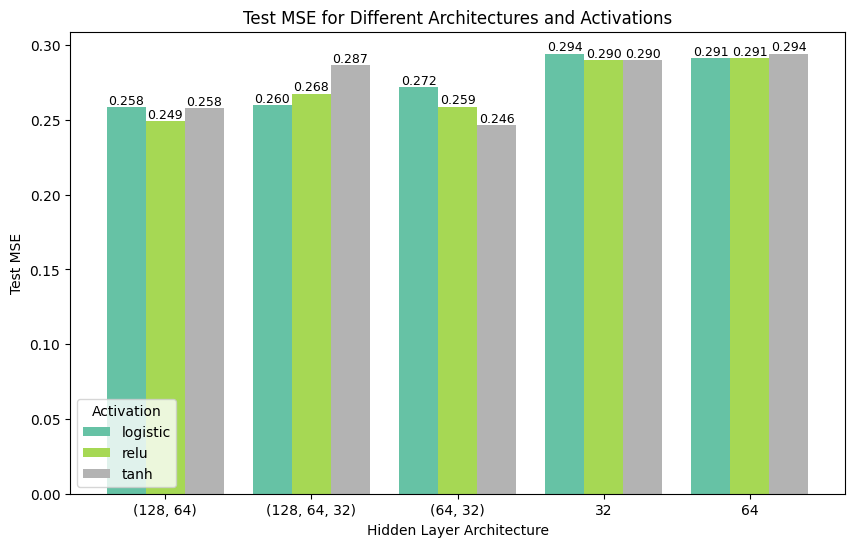

In [ ]:
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1) Load and preprocess data
# 1) 加载并预处理数据
# ============================================================


# Load the California Housing dataset from sklearn.

# 从 sklearn 加载加州房价数据集

data = fetch_california_housing()


# Convert the feature matrix to a pandas DataFrame for easier manipulation.

# 将特征矩阵转换为 DataFrame，方便后续数据处理

X = pd.DataFrame(data.data, columns=data.feature_names)


# Convert target values (house prices) to a pandas Series.

# 将房价目标值转换为 Series

y = pd.Series(data.target, name="MedHouseVal")


# ------------------------------------------------------------
# Remove missing values
# 删除缺失值
# ------------------------------------------------------------


# Remove rows containing missing values to ensure clean training data.

# 删除包含缺失值的行，保证训练数据干净

X = X.dropna()
y = y.loc[X.index]


# ------------------------------------------------------------
# Split dataset into train / validation / test
# 数据集划分：训练集 / 验证集 / 测试集
# ------------------------------------------------------------


# First split data into training+validation (80%) and test set (20%).

# 先将数据划分为训练+验证集（80%）和测试集（20%）

X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.2, random_state=26
)

# Then split training+validation into actual training (72%) and validation (8%).

# 再将训练+验证集划分为训练集（72%）和验证集（8%）

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.1, random_state=26
)


# ------------------------------------------------------------
# Standardize features
# 特征标准化
# ------------------------------------------------------------

# 
# Standardization rescales features so they have mean = 0 and std = 1.
# This helps neural networks train more efficiently.
# Important: fit only on the training set to avoid data leakage.
#
# 
# 标准化会让每个特征变成均值0、标准差1，
# 这样神经网络训练会更稳定、更快收敛。
# 注意：只在训练集上 fit，避免数据泄漏。

scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X.columns,
    index=X_train.index
)

X_val = pd.DataFrame(
    scaler.transform(X_val),
    columns=X.columns,
    index=X_val.index
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X.columns,
    index=X_test.index
)


# ============================================================
# 2) Define architectures and activation functions
#  定义不同的神经网络结构和激活函数
# ============================================================


# Each tuple represents the number of neurons in hidden layers.
# Example:
# (64,32) means two hidden layers with 64 and 32 neurons.
#

# 每个元组表示隐藏层结构。
# 例如：
# (64,32) 表示两个隐藏层，分别有 64 和 32 个神经元。

architectures = [
    (32),
    (64),
    (64,32),
    (128,64),
    (128,64,32)
]


# Activation functions to test.
# tanh  → nonlinear symmetric activation
# relu  → widely used deep learning activation
# logistic → sigmoid nonlinear activation
#

# 要测试的激活函数：
# tanh → 对称的非线性函数
# relu → 深度学习中常用激活函数
# logistic → Sigmoid 非线性激活函数

activations = ['tanh', 'relu', 'logistic']


# ============================================================
# 3) Train models and collect Test MSE
#  训练模型并记录测试集 MSE
# ============================================================

results = []

for arch in architectures:
    for act in activations:

        
        # Create a neural network model with the current architecture
        # and activation function.
        
        # 创建一个神经网络模型，使用当前的隐藏层结构和激活函数

        model_test_act = MLPRegressor(
            hidden_layer_sizes=arch,
            activation=act,
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=700,
            random_state=26
        )

        
        # Train the model on the training dataset.
    
        # 在训练集上训练模型

        model_test_act.fit(X_train, y_train)

      
        # Predict house prices on the test set.
      
        # 在测试集上进行预测

        test_pred_act = model_test_act.predict(X_test)

        
        # Compute Mean Squared Error (MSE).
        # Lower MSE indicates better prediction performance.
       
        # 计算均方误差（MSE）。
        # MSE 越小，模型预测效果越好。

        test_mse_act = mean_squared_error(y_test, test_pred_act)

        results.append({
            'Architecture': str(arch),
            'Activation': act,
            'Test_MSE': test_mse_act
        })

        print(f"Architecture: {arch}, Activation: {act}, Test MSE: {test_mse_act:.4f}")


# ============================================================
# 4) Convert results to DataFrame
#  将结果转换为表格
# ============================================================


# Convert the results list into a pandas DataFrame
# and reshape it using pivot for easier visualization.

# 将实验结果转换为 DataFrame，
# 再使用 pivot 变成适合绘图的格式。

results_df = pd.DataFrame(results)

pivot_table = results_df.pivot(
    index='Architecture',
    columns='Activation',
    values='Test_MSE'
)
# -------------------------------------------------
# Fix architecture order for plotting
# 按定义的顺序重新排列架构
# -------------------------------------------------

order = ['(32,)', '(64,)', '(64, 32)', '(128, 64)', '(128, 64, 32)']
pivot_table = pivot_table.reindex(order)

print("\n=== Test MSE Table ===")
print(pivot_table)


# ============================================================
# 5) Plot grouped bar chart
# 绘制分组柱状图
# ============================================================

# Create a grouped bar chart showing Test MSE for each
# architecture and activation combination.
#
# 绘制分组柱状图，
# 展示不同隐藏层结构和激活函数组合的 Test MSE。

ax = pivot_table.plot(
    kind='bar',
    figsize=(10,6),
    width=0.8,
    colormap='Set2'
)

plt.ylabel("Test MSE")
plt.xlabel("Hidden Layer Architecture")
plt.title("Test MSE for Different Architectures and Activations")
plt.xticks(rotation=0)
plt.legend(title="Activation")




# ------------------------------------------------------------
# Add value labels above bars using patches
# 使用 patches 自动获取每个柱子的位置，避免坐标误差
# ------------------------------------------------------------

for p in ax.patches:

  
    # Get bar height (MSE value)
    # 获取柱子的高度（MSE值）

    height = p.get_height()

   
    # Place text at the center top of each bar
    # 在每个柱子的顶部中心位置标注数值

    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )
plt.show()

In [16]:
# model (no internal early stopping, since you already have X_val)
model = MLPRegressor(
    hidden_layer_sizes=(64, 32),
    activation='tanh',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=700,
    early_stopping=True,
    random_state=26
)

model.fit(X_train, y_train)
#测试集和预测集的预测
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)

# 训练集预测
train_pred = model.predict(X_train)
# 计算训练误差
train_mse = mean_squared_error(y_train, train_pred)

print("Baseline Train MSE:", train_mse)#加入是为了判断是不是欠拟合或者过拟合
print("Validation MSE:", mean_squared_error(y_val, val_pred))#Mean Squared Error（均方误差）
print("Test MSE:", mean_squared_error(y_test, test_pred))

Baseline Train MSE: 0.26190524338772764
Validation MSE: 0.3057820937943312
Test MSE: 0.2668096262952686


Architecture: (32,), Activation: tanh, Validation MSE: 0.3137
Architecture: (32,), Activation: relu, Validation MSE: 0.3262
Architecture: (32,), Activation: logistic, Validation MSE: 0.3210
Architecture: (64,), Activation: tanh, Validation MSE: 0.3140
Architecture: (64,), Activation: relu, Validation MSE: 0.3272
Architecture: (64,), Activation: logistic, Validation MSE: 0.3120
Architecture: (64, 32), Activation: tanh, Validation MSE: 0.2841
Architecture: (64, 32), Activation: relu, Validation MSE: 0.2890
Architecture: (64, 32), Activation: logistic, Validation MSE: 0.3078
Architecture: (128, 64), Activation: tanh, Validation MSE: 0.2798
Architecture: (128, 64), Activation: relu, Validation MSE: 0.2793
Architecture: (128, 64), Activation: logistic, Validation MSE: 0.2855


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (600) reached and the optimization hasn't converged yet.
  warnings.warn(


Architecture: (128, 64, 32), Activation: tanh, Validation MSE: 0.3118
Architecture: (128, 64, 32), Activation: relu, Validation MSE: 0.2987
Architecture: (128, 64, 32), Activation: logistic, Validation MSE: 0.2941

=== Validation MSE Table ===
Activation     logistic      relu      tanh
Architecture                               
(128, 64)      0.285536  0.279279  0.279801
(128, 64, 32)  0.294129  0.298666  0.311764
(32,)          0.320968  0.326200  0.313691
(64, 32)       0.307780  0.289044  0.284061
(64,)          0.312038  0.327152  0.313980


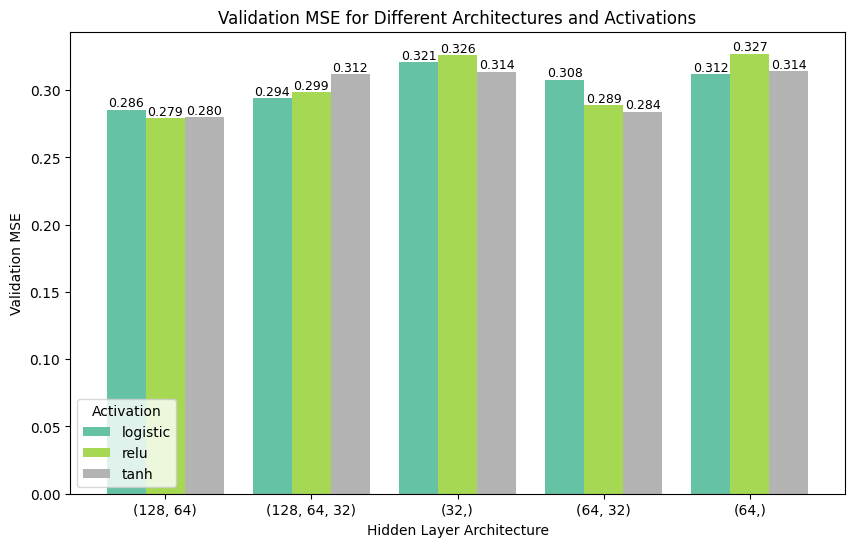

In [ ]:
import matplotlib.pyplot as plt
# 1) Define architectures and activation functions
#  定义不同的神经网络结构和激活函数
# ============================================================

# Each tuple represents the number of neurons in hidden layers.
# Example:
# (64,32) means two hidden layers with 64 and 32 neurons.
#
# 每个元组表示隐藏层结构。
# 例如：
# (64,32) 表示两个隐藏层，分别有 64 和 32 个神经元。

architectures = [
    (32,),
    (64,),
    (64,32),
    (128,64),
    (128,64,32)
]

# Activation functions to test.
# tanh  → nonlinear symmetric activation
# relu  → widely used deep learning activation
# logistic → sigmoid nonlinear activation
#
# 要测试的激活函数：
# tanh → 对称的非线性函数
# relu → 深度学习中常用激活函数
# logistic → Sigmoid 非线性激活函数

activations = ['tanh', 'relu', 'logistic']


# ============================================================
# 2) Train models and collect Test MSE
# 训练模型并记录测试集 MSE
# ============================================================

results = []

for arch in architectures:
    for act in activations:

        
        # Create a neural network model with the current architecture
        # and activation function.
        #
        # 创建一个神经网络模型，使用当前的隐藏层结构和激活函数

        model_test_act = MLPRegressor(
            hidden_layer_sizes=arch,
            activation=act,
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=700,
            n_iter_no_change=10,
            early_stopping=False,
            random_state=26
        )

        
        # Train the model on the training dataset.
        # 在训练集上训练模型

        model_test_act.fit(X_train, y_train)

        
        # Predict house prices on the validation set
        # 在验证集上进行预测

        val_pred_act = model_test_act.predict(X_val)

        # Compute Mean Squared Error (MSE) on validation set
        # 计算验证集上的均方误差

        val_mse_act = mean_squared_error(y_val, val_pred_act)

        results.append({
            'Architecture': str(arch),
            'Activation': act,
            'Validation_MSE': val_mse_act
        })

        print(f"Architecture: {arch}, Activation: {act}, Validation MSE: {val_mse_act:.4f}")

# ============================================================
# 3) Convert results to DataFrame
# 将结果转换为表格
# ============================================================

# 
# Convert the results list into a pandas DataFrame
# and reshape it using pivot for easier visualization.
#

# 将实验结果转换为 DataFrame，
# 再使用 pivot 变成适合绘图的格式。

results_df = pd.DataFrame(results)

pivot_table = results_df.pivot(
    index='Architecture',
    columns='Activation',
    values='Validation_MSE'
)

# -------------------------------------------------
# Fix architecture order for plotting
# 按定义的顺序重新排列架构
# -------------------------------------------------

order = ['(32,)', '(64,)', '(64, 32)', '(128, 64)', '(128, 64, 32)']
pivot_table = pivot_table.reindex(order)

print("\n=== Validation MSE Table ===")
print(pivot_table)


# ============================================================
# 4) Plot grouped bar chart
#  绘制分组柱状图
# ============================================================

# Create a grouped bar chart showing Validation MSE for each
# architecture and activation combination.
#

# 绘制分组柱状图，
# 展示不同隐藏层结构和激活函数组合的 Validation MSE。

ax = pivot_table.plot(
    kind='bar',
    figsize=(10,6),
    width=0.8,
    colormap='Set2'
)

plt.ylabel("Validation MSE")
plt.xlabel("Hidden Layer Architecture")
plt.title("Validation MSE for Different Architectures and Activations")
plt.xticks(rotation=0)
plt.legend(title="Activation")




# ------------------------------------------------------------
# Add value labels above bars using patches
# 使用 patches 自动获取每个柱子的位置，避免坐标误差
# ------------------------------------------------------------

for p in ax.patches:


    # Get bar height (MSE value)
    # 获取柱子的高度（MSE值）

    height = p.get_height()

  
    # Place text at the center top of each bar
    # 在每个柱子的顶部中心位置标注数值





# Add value labels above bars
for p in ax.patches:
    height = p.get_height()
    ax.text(
        p.get_x() + p.get_width() / 2,
        height,
        f"{height:.3f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

plt.show()